# Домашнее задание 3. Модели классификации и нелинейные зависимости

Один банк обратился к вам за помощью: он хочет разработать кампанию лояльности по удержанию клиентов. Для этого он хочет прогнозировать вероятности оттока клиентов и определять, уйдет ли клиент в ближайшее время. Чтобы решить эту задачу, вам предстоит построить модель машинного обучения, которая будет прогнозировать этот отток клиентов.

Технически необходимо построить классификатор, который позволит своевременно определять уходящих клиентов банка, оценить качество построенных моделей и проинтерпретировать результаты.

---

### Описание данных

| Признак | Описание |
| ------ | -------- |
| `RowNumber` | номер строки таблицы |
| `CustomerId` | идентификатор клиента |
| `Surname` | фамилия клиента |
| `CreditScore` | кредитный рейтинг клиента |
| `Geography` | страна проживания клиента |
| `Gender` | пол клиента |
| `Age` | возраст клиента |
| `Tenure` | сколько лет клиент пользуется банком |
| `Balance` | сумма средств на счетах клиента |
| `NumOfProduct` | количество банковских продуктов |
| `HasCrCard` | наличие кредитной карты (1 — да, 0 — нет) |
| `IsActiveMember` | активный клиент (1 — да, 0 — нет) |
| `EstimatedSalary` | предполагаемая заработная плата |

**Целевая переменная**

`Exited` — индикатор оттока клиента (1 — ушел, 0 — остался).



In [1]:
# Импорт нужных библиотек и моделей,
# Добавляйте в ячейку все, что потребуется

# Работа с данными и вычислениями
import numpy as np
import pandas as pd
from scipy.stats import skew

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Машинное обучение
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import svm
from sklearn import neighbors
from sklearn import calibration
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV

## Часть I. Знакомство и анализ

В этой части вам предстоит провести первичный анализ данных. Выполним ряд проверок и при необходимости почистим данные.

### Задание 1.1

**Проверим данные на полноту и качество.**  
- Проверьте наличие пропусков в данных и при необходимости обработайте их.  
- Проверьте наличие выбросов и при необходимости почистите их.
- Проверьте наличие дубликатов и при необходимости почистите их.
- Подумайте, есть ли в данных неинформативные признаки, при необходимости удалите их.
- Не забудьте записать наблюдения в виде небольшого вывода.

In [2]:
df = pd.read_csv('bank_clients.csv')

df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
1,16,15643966,Goforth,616,Germany,Male,45,3,143129.41,2,0,1,64327.26,0
2,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
3,27,15736816,Young,756,Germany,Male,36,2,136815.64,1,1,1,170041.95,0
4,29,15728693,McWilliams,574,Germany,Female,43,3,141349.43,1,1,1,100187.43,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2504,9983,15768163,Griffin,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
2505,9985,15696175,Echezonachukwu,602,Germany,Male,35,7,90602.42,2,1,1,51695.41,0
2506,9987,15581736,Bartlett,673,Germany,Male,47,1,183579.54,2,0,1,34047.54,0
2507,9991,15798964,Nkemakonam,714,Germany,Male,33,3,35016.60,1,1,0,53667.08,0


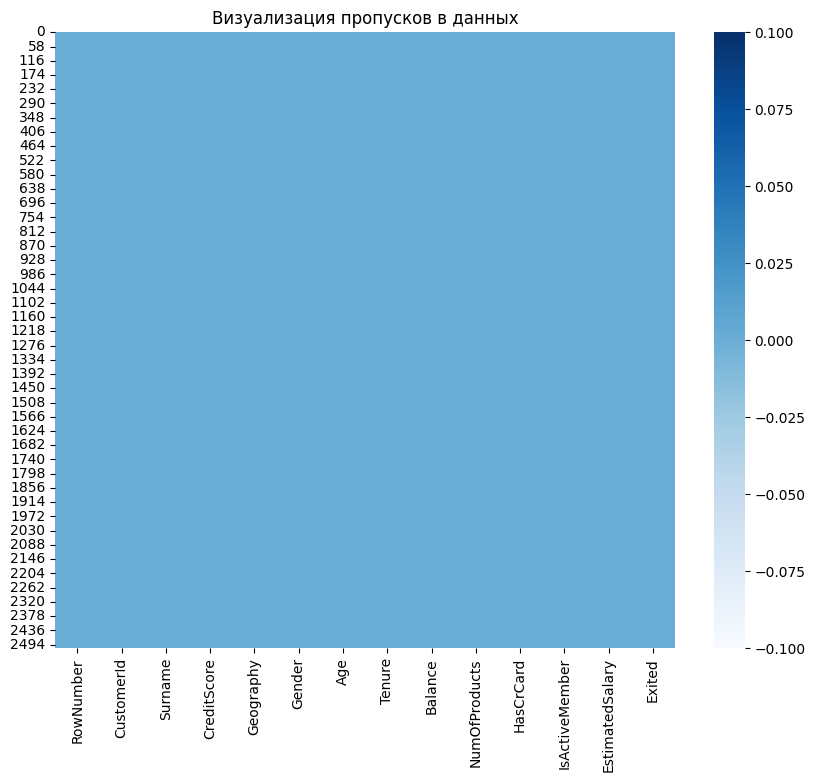

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.isnull(), cmap='Blues')
plt.title('Визуализация пропусков в данных')
plt.show()

In [4]:
for col in df.columns:
    null = df[col].isnull().sum()
    if null > 0:
        print(f'В столбце {col} {null} пропусков')
    else:
        print(f'В столбце {col} нет пропусков')

В столбце RowNumber нет пропусков
В столбце CustomerId нет пропусков
В столбце Surname нет пропусков
В столбце CreditScore нет пропусков
В столбце Geography нет пропусков
В столбце Gender нет пропусков
В столбце Age нет пропусков
В столбце Tenure нет пропусков
В столбце Balance нет пропусков
В столбце NumOfProducts нет пропусков
В столбце HasCrCard нет пропусков
В столбце IsActiveMember нет пропусков
В столбце EstimatedSalary нет пропусков
В столбце Exited нет пропусков


In [5]:
df['CustomerId'].duplicated().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Geography'].unique()

array(['Germany'], dtype=object)

In [8]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography'], axis=1)

df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,376,Female,29,4,115046.74,4,1,0,119346.88,1
1,616,Male,45,3,143129.41,2,0,1,64327.26,0
2,653,Male,58,1,132602.88,1,1,0,5097.67,1
3,756,Male,36,2,136815.64,1,1,1,170041.95,0
4,574,Female,43,3,141349.43,1,1,1,100187.43,0
...,...,...,...,...,...,...,...,...,...,...
2504,655,Female,46,7,137145.12,1,1,0,115146.40,1
2505,602,Male,35,7,90602.42,2,1,1,51695.41,0
2506,673,Male,47,1,183579.54,2,0,1,34047.54,0
2507,714,Male,33,3,35016.60,1,1,0,53667.08,0


**Вывод:**

Имеем чистый датасет - 2509 строк $\times$ 14 столбцов, после удаления `RowNumber`, `CustomerId`, `Surname`, `Geography` как неинформативных столбцов осталось всего 10 столбцов.

Данные чистые - дубликатов по `CustomerId` нет, полный дублей также нет.

Пропуски не наблюдаем.

### Задание 1.2

**Проверим распределения:**  
- Посмотрите на распределение целевого признака `Exited`.
- Изучите распределения остальных признаков, а также парные зависимости (можете воспользоваться `pairplot`).
- Зафиксируйте наблюдения в небольшом выводе.

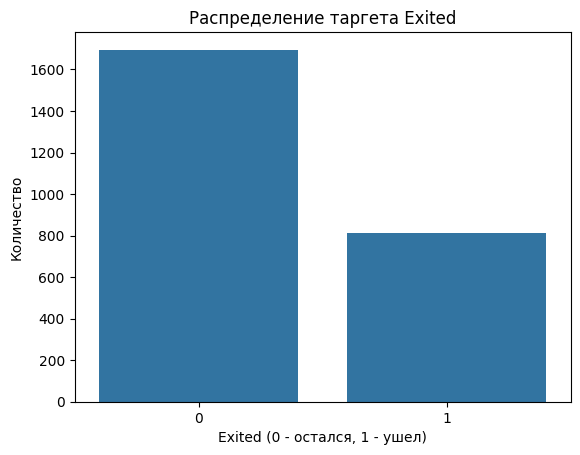

In [9]:
sns.countplot(x='Exited', data=df)
plt.title('Распределение таргета Exited')
plt.xlabel('Exited (0 - остался, 1 - ушел)')
plt.ylabel('Количество')
plt.show()

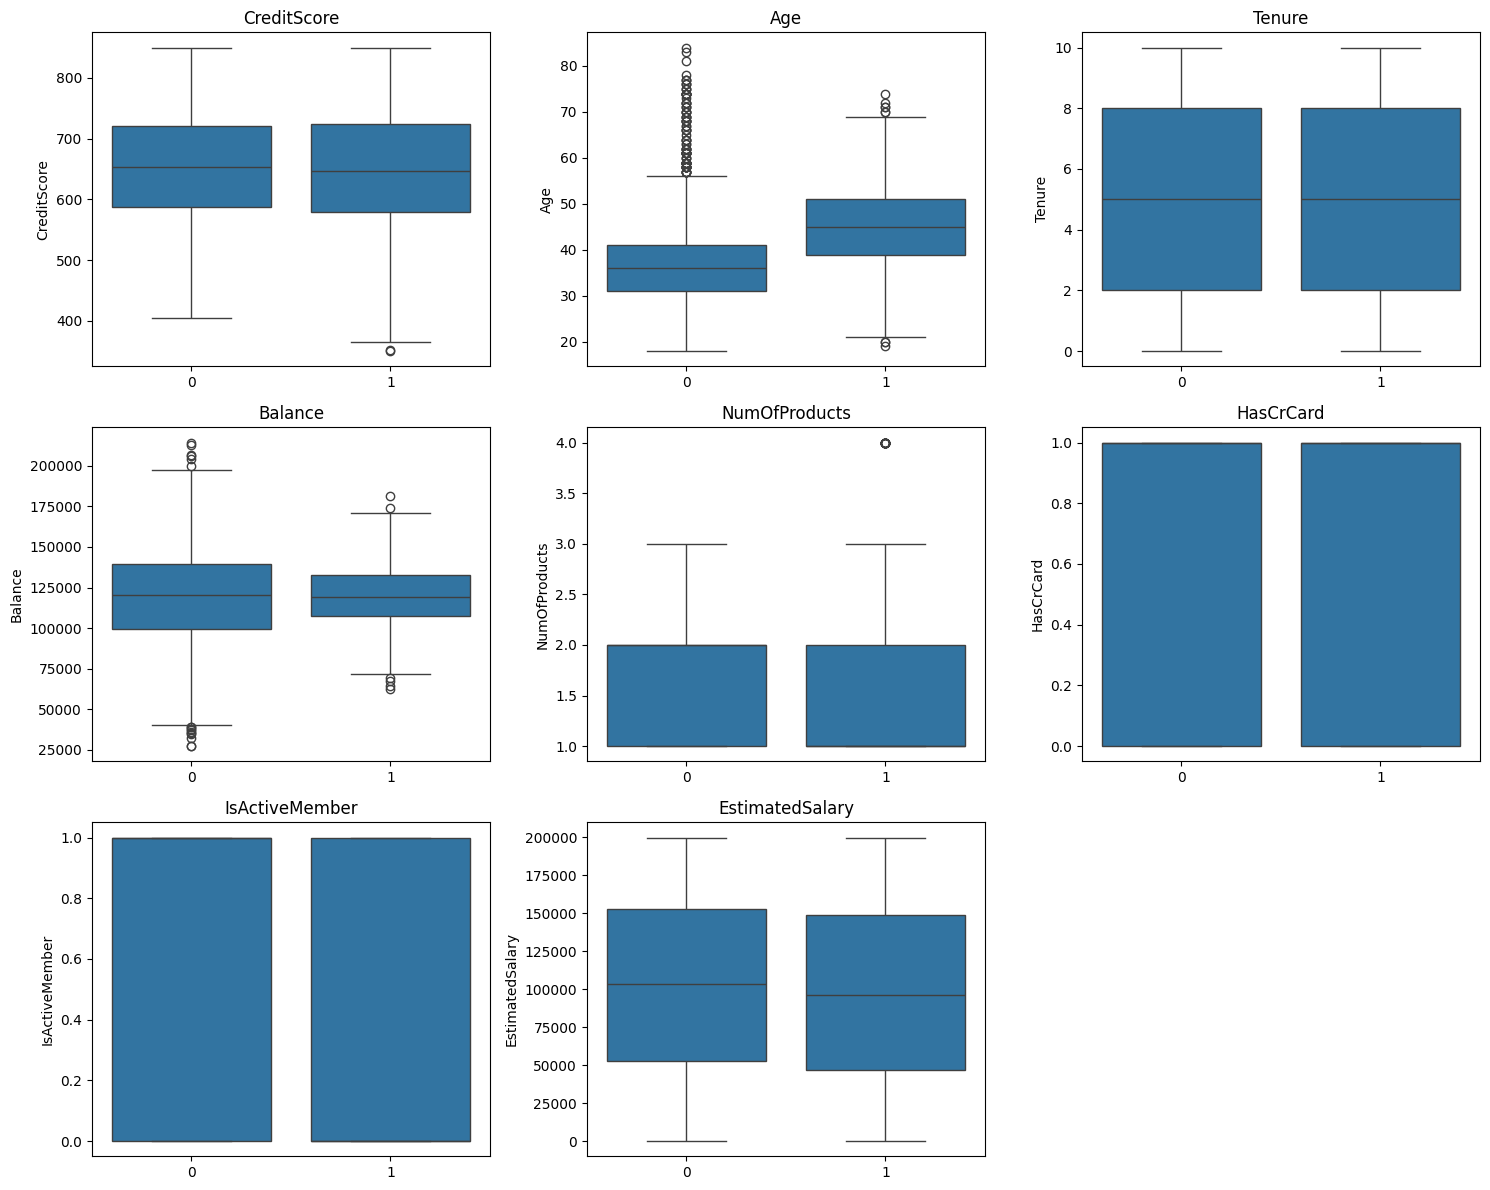

In [10]:
num_cols = df.select_dtypes(include=['int', 'float']).columns
num_cols = [col for col in num_cols if col != 'Exited']

n_cols = 8
n_rows = 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Exited', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

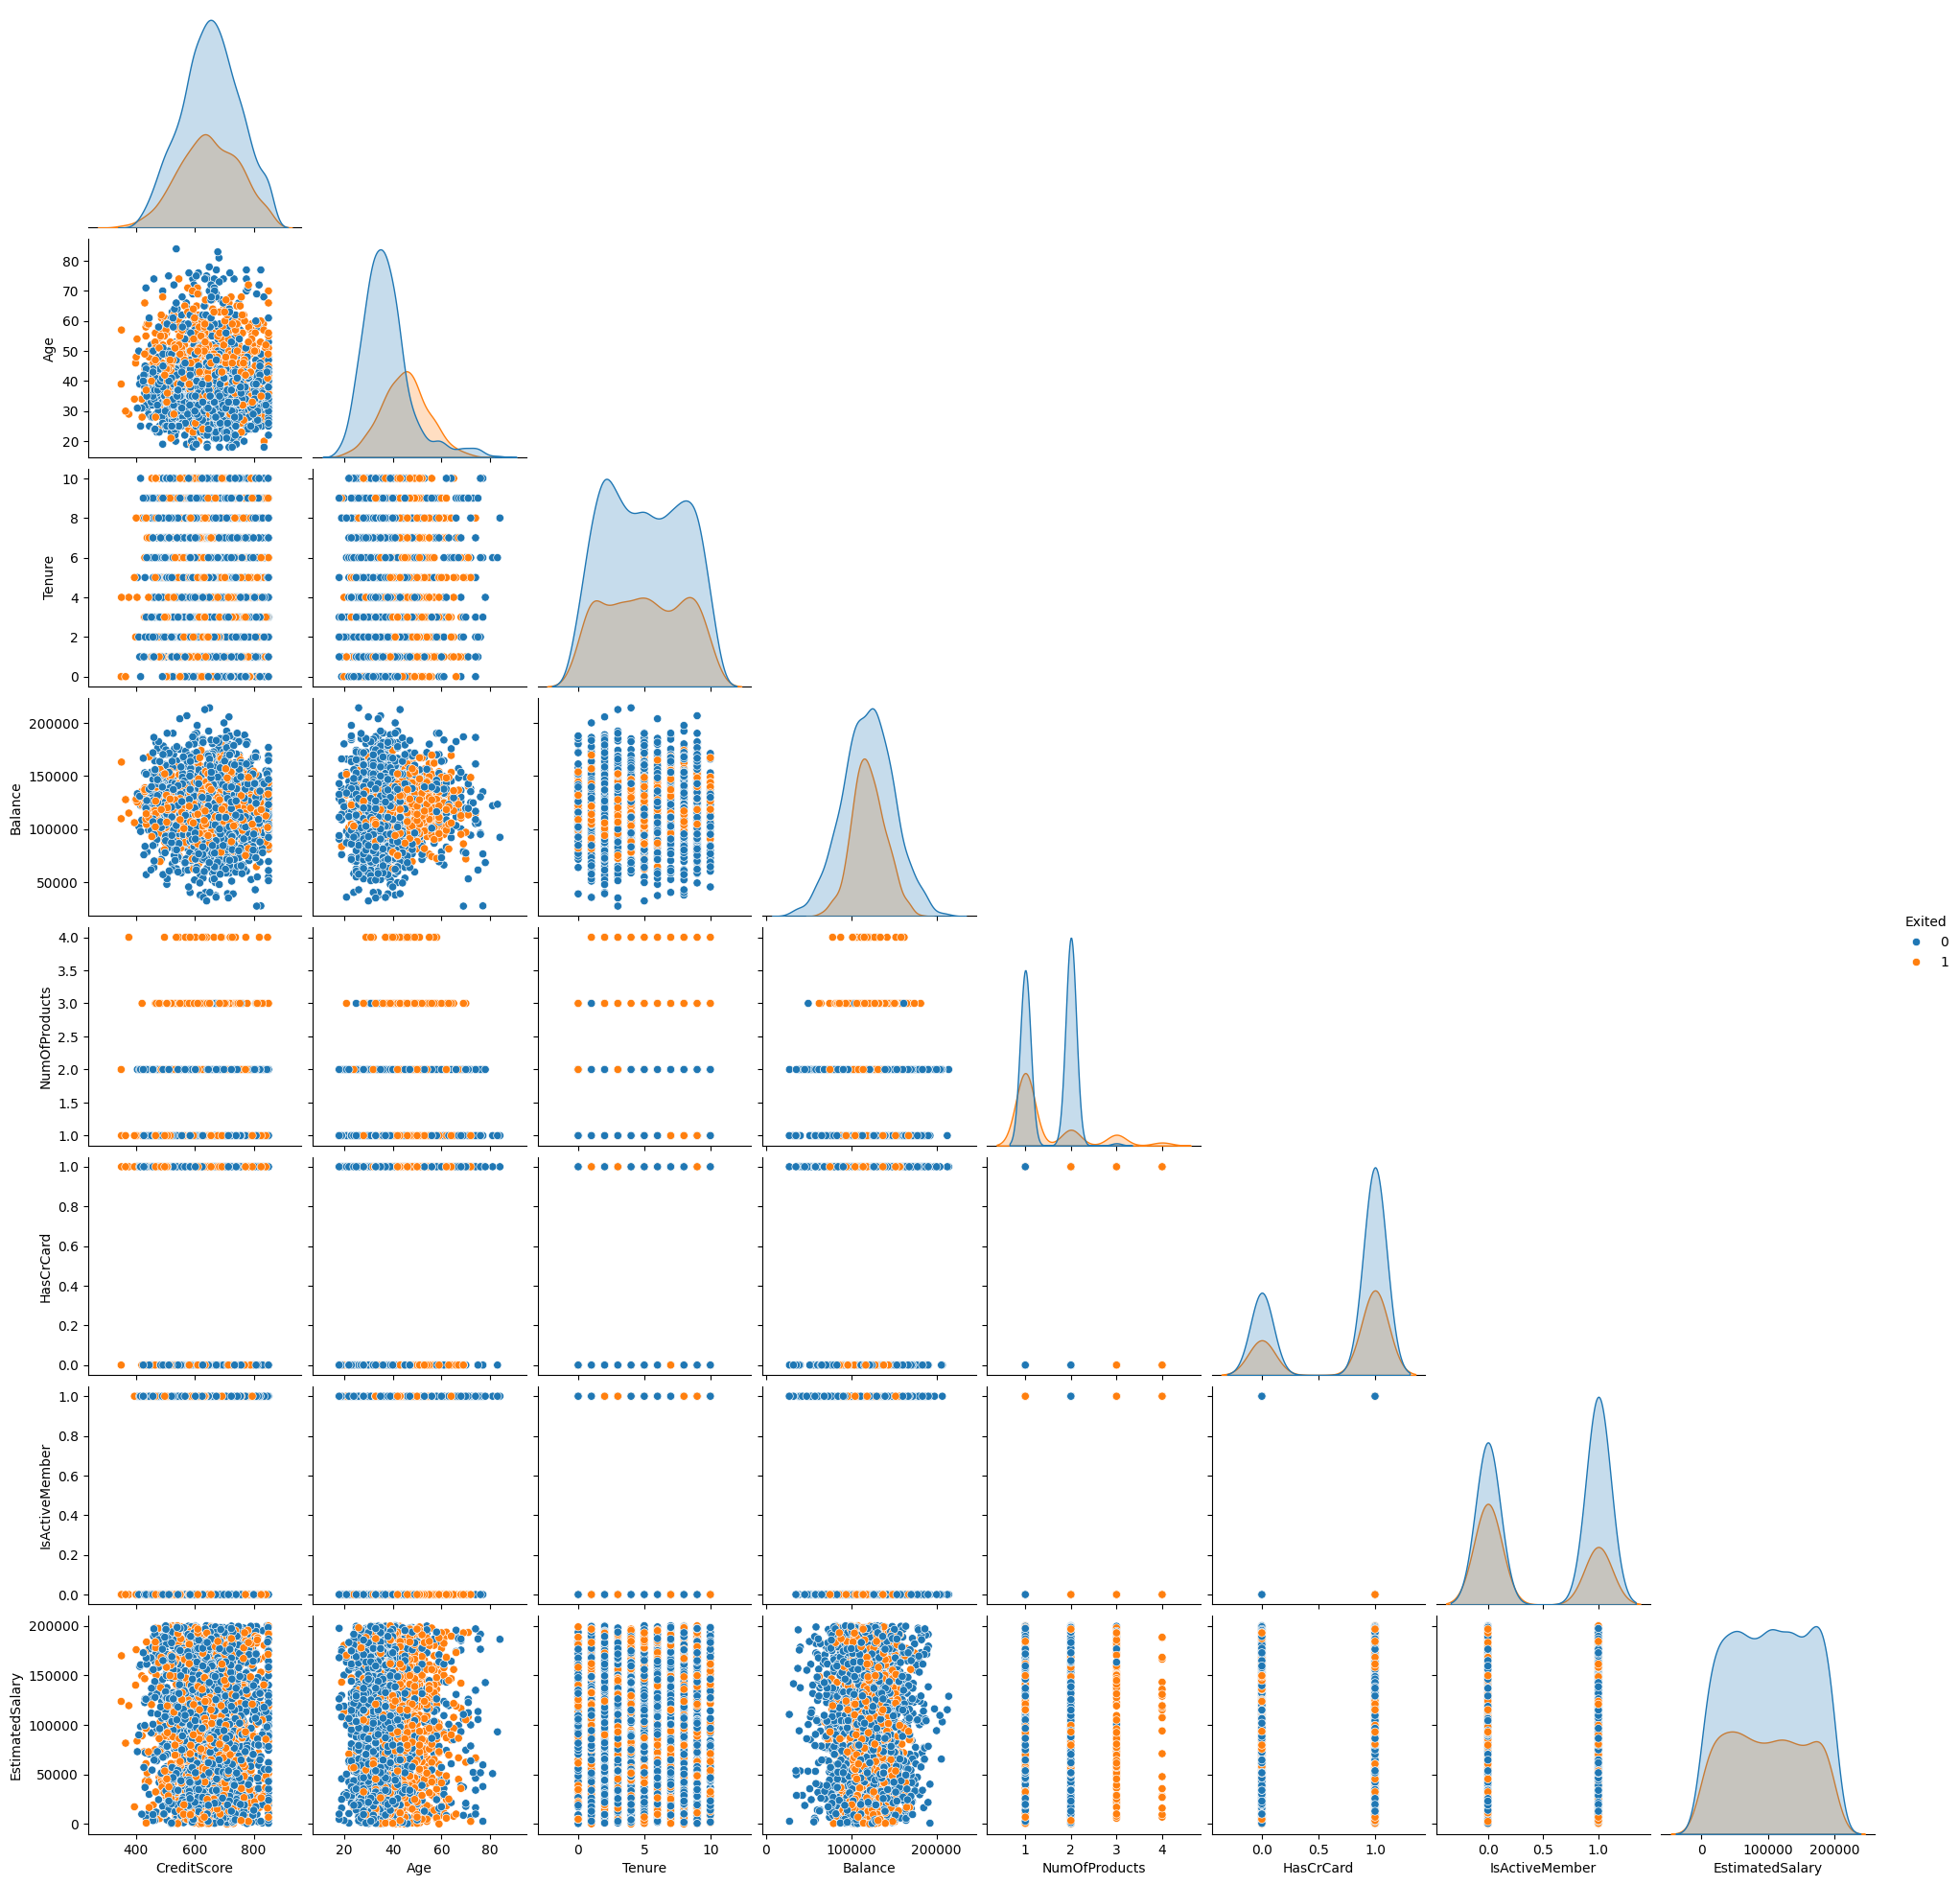

In [11]:
sns.pairplot(df, hue='Exited', corner=True)
plt.show()

**Вывод:**

Ключевой вопрос, который мы должны сеюбе задать перед анализом - чем различаются признаки для разных классов?

Сразу бросается в глаза признак `Age` - возраст клиента.

Из графика видно, что средний возраст оставшихся клиентов в среднем составляет от 20 до 40 лет, причем пожилые клиенты определяются как выбросы.

Это значит, что в этой группе подавляющее большинство людей - молодежь, так как выбросы определяются статистически.

$$
\text{Верхний ус}: Q3 + 1.5 \times IQR
$$


Для клиентов с меткой классса 1 (ушедшие) ситуация ровно противоположная.

Мы видим, что в этой группе люди имеют возраст от 40 до 60 лет (преимущественно).

Пожилые же как выбросы фигурируют гораздо реже - это значит, что в этой группе гораздо больше пожилых людей.

`NumOfProducts` формирует кластер - когда число продуктов у клиента становится равным 3+, риск, что он уйдет, становится значительно выше - мы видим это из pairplot.

Остальные признаки не представляют большого интереса.

### Задание 1.3

**Проверим мультиколлинеарность:**  
- Постройте матрицу корреляций и визуализируйте ее.  
- Проанализируйте наличие мультиколлинеарных признаков (в качестве порога можно взять ±0.7) и удалите ненужные при необходимости.
- Отразите наблюдения в небольшом выводе.

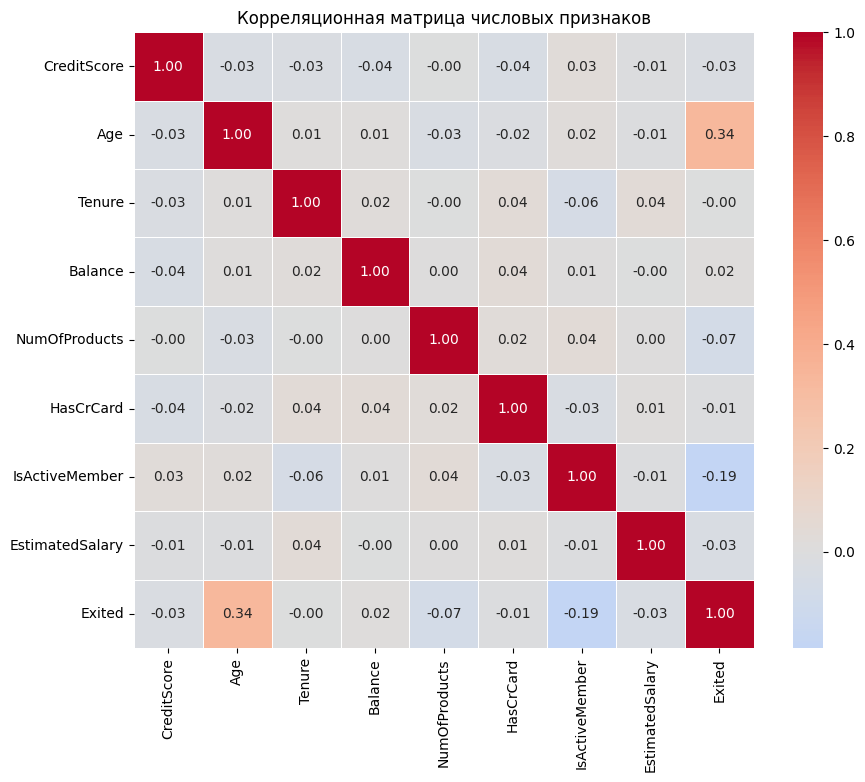

In [12]:
plt.figure(figsize=(10, 8))
corr_table = df.corr(numeric_only=True)
sns.heatmap(corr_table, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

**Вывод:**

Мы видим, что признаки крайне слабо коррелируют друг с другом - это плохо для логистической регрессии, так как она предполагает линейную зависимость - модель не увидит связи, будет неустойчивой и слабой.

Признаки сами по себе не очень значимы.

Возможно, придется прибегнуть к нелинейным зависимостям и проверить гипотезы, на которые нам жирно намекнул pairplot.

Можно прибегнуть к нелинейным моделям, которые сами найдут зависимости, а можно усилить логистическую регрессию сильным бинарным признаком из нелинейной связи.

### Задание 1.4

**Расширим датасет с помощью методов Feature Engineering:**
* `BalanceSalaryRatio` — отношение баланса на счетах к заработной плате клиента;
* `TenureByAge` — отношение времени пользования услугами банка к возрасту клиента;
* `CreditScoreGivenAge` — отношение кредитного рейтинга к возрасту клиента.

In [13]:
df['BalanceSalaryRatio'] = df['Balance'] / df['EstimatedSalary']
df['TenureByAge'] = df['Tenure'] / df['Age']
df['CreditScoreGivenAge'] = df['CreditScore'] / df['Age']

# и от себя добавим признак количества 3+ продуктов - создали сильный бинарный признак из нелинейной связи
df['Products_3_plus'] = (df['NumOfProducts'] >= 3).astype(int)

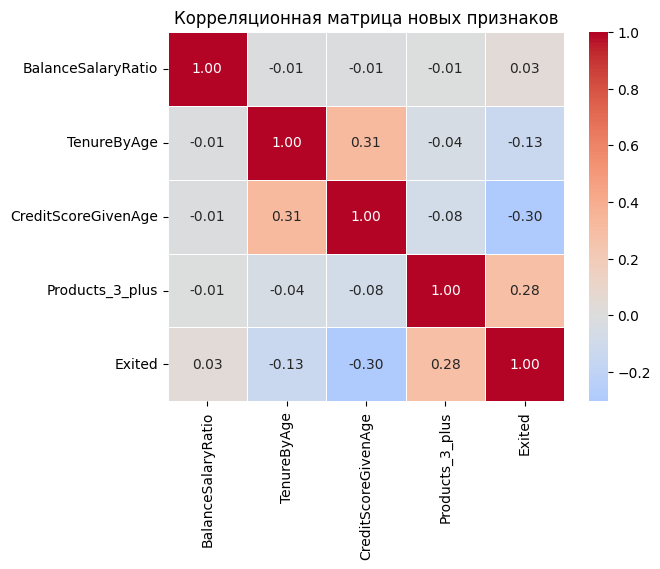

In [14]:
corr_table = df[['BalanceSalaryRatio', 'TenureByAge', 'CreditScoreGivenAge', 'Products_3_plus', 'Exited']].corr(numeric_only=True)

sns.heatmap(corr_table, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляционная матрица новых признаков')
plt.show()

### Задание 1.5

**Закодируем категориальные признаки:**
* Для начала выберите признаки для кодирования.
* Затем подберите к каждому подходящий способ — закодируйте и сформируйте единый датафрейм.
* Обоснуйте в небольшом выводе, почему выбрали тот или иной способ.

In [15]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

**Вывод:**

У нас всего один категориальный признак `Gender` - закодируем его через Label Encoding, так как это бинарный признак, и в нем всего два уникальных значения.

Если бы значения было 3+, лучше было бы выбрать One-Hot Encoding.

Особенно хорошо последнее было бы для CatBoost.

### Задание 1.6

**Разделим на тренировочную и тестовую выборки:**
* Установите соотношение 80/20, `random_state=42` и учитывайте дисбаланс при его наличии.

In [16]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Задание 1.7

**Выполним масштабирование/нормализацию:**
* Выберите подходящий способ масштабирования или нормализации данных.
* Примените его для обучающей и тестовой выборки.
* Обоснуйте в небольшом выводе, почему выбрали тот или иной способ.

In [17]:
for col in X_train_raw.columns:
    print(col, skew(X_train_raw[col]))

CreditScore -0.08998675926342502
Gender -0.10677866367156723
Age 0.82843681484378
Tenure 0.029982143299244954
Balance -0.007647065135817698
NumOfProducts 1.0302125660459431
HasCrCard -0.9525479150773793
IsActiveMember 0.038871315723013715
EstimatedSalary 0.011718819411891618
BalanceSalaryRatio 43.364360520723174
TenureByAge 0.5517087657441683
CreditScoreGivenAge 0.791269174142566
Products_3_plus 4.186995057870129


In [18]:
binary_features = ['Gender', 'HasCrCard', 'IsActiveMember', 'Products_3_plus']
norm_skew_features = ['CreditScore', 'Age', 'Tenure', 'Balance','EstimatedSalary',
                      'TenureByAge', 'CreditScoreGivenAge']
extra_skew_features = ['BalanceSalaryRatio', 'NumOfProducts']

preprocessor = ColumnTransformer([
    ('лог-маштаб', Pipeline([
        ('лог1п', FunctionTransformer(np.log1p)),
        ('стандартизация', StandardScaler())
    ]), extra_skew_features),

    ('стандартизация', StandardScaler(), norm_skew_features),

    ('пропускаем', 'passthrough', binary_features)
])

model_pipeline = Pipeline([
    ('предобработка', preprocessor),
    ('классификатор', LogisticRegression(random_state=42))
])

**Вывод:**

Благодаря скошенности мы можем определить столбцы, которые требует разные подходы перед подачей в модель:

`CreditScore`: -0.08998675926342502

`Gender`: -0.10677866367156723

`Age`: 0.82843681484378

`Tenure`: 0.029982143299244954

`Balance`: -0.007647065135817698

`NumOfProducts`: 1.0302125660459431

`HasCrCard`: -0.9525479150773793

`IsActiveMember`: 0.038871315723013715

`EstimatedSalary`: 0.011718819411891618

`BalanceSalaryRatio`: 43.364360520723174

`TenureByAge`: 0.5517087657441683

`CreditScoreGivenAge`: 0.791269174142566

`Products_3_plus`: 4.186995057870129

Маштабирование целевой переменной не имеет смысла, так как это метка класса.

В пайплайне отразил русские названия для русской команды ;)

Также применили градиентный спуск через .fit для логистической регрессии через sclearn и получили первые предсказания.

Результаты логистической регрессии после предобработки данных:

1. Общая точность (accuracy): 76% — модель правильно классифицирует 3 из 4 клиентов

2. Для критически важного класса "уходящие клиенты":
   - Precision 66%: из 100 предсказанных уходов 66 реальны - неплохая точность
   - Recall 52%: находим только половину уходящих - есть потенциал для улучшения
   - F1-score 58%: сбалансированная метрика качества

Модель рабочая, но требует доработки для повышения полноты (recall) выявления уходящих клиентов.

In [19]:
model_pipeline.fit(X_train_raw, y_train)

Pipeline(steps=[('предобработка',
                 ColumnTransformer(transformers=[('лог-маштаб',
                                                  Pipeline(steps=[('лог1п',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('стандартизация',
                                                                   StandardScaler())]),
                                                  ['BalanceSalaryRatio',
                                                   'NumOfProducts']),
                                                 ('стандартизация',
                                                  StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'EstimatedSalary',
                                                   'TenureByAge',
                                                   'CreditScoreGivenAge']),
                                                 ('пропускаем', 'passthrough',
                                                  ['Gender', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'Products_3_plus'])])),
                ('классификатор', LogisticRegression(random_state=42))])

In [20]:
y_pred = model_pipeline.predict(X_test_raw)

In [21]:
print(classification_report(y_test, y_pred, target_names=['Останется', 'Уйдет']))  # порядку классов в данных соответствует

              precision    recall  f1-score   support

   Останется       0.79      0.87      0.83       339
       Уйдет       0.67      0.53      0.59       163

    accuracy                           0.76       502
   macro avg       0.73      0.70      0.71       502
weighted avg       0.75      0.76      0.75       502



## Часть II. Линейные модели

Приступаем к моделированию. В этой части построим baseline — простейшее решение, от которого будем отталкиваться. Вдруг базовая логистическая регрессия уже будет приемлема по качеству, и необходимости в сложных моделях не будет?


### Задание 2.1

**Для начала определим метрику, на которую будем ориентироваться.**

По условию задачи, наша модель должна своевременно предсказывать отток клиентов. Известно, что для сохранения клиентов банк будет использовать ресурсы кол-центра, и клиентам, у которых вероятность оттока наиболее высока, будут сделаны специальные предложения. Ресурсы, выделяемые на сохранение клиентов, ограничены, поэтому нам важно минимизировать количество звонков. Однако в то же время необходимо сохранить как можно больше клиентов.

Таким образом, нам бы хотелось минимизировать как ложноположительные и ложноотрицательные срабатывания модели.

* Какую метрику в данной задаче вы будете пытаться улучшить? Обоснуйте свой выбор.

**Ответ:** F1, так как нам важно найти баланс между экономией ресурсов (звонки) и уходом клиентов (потеря прибыли).

### Задание 2.2

**Обучите модель логистической регрессии:**
* Реализуйте алгоритм вручную и сравните с `LogisticRegression` из sklearn по коэффициентам и метрикам (подробнее п.3).
* Позаботьтесь о воспроизводимости результата, установив конкретное значение гиперпараметра `random_state` (например, число 42).
* Сделайте предсказание меток классов для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики на обеих выборках. Также выберите метрику, которая не зависит от порога — она будет удобна для сравнения разных моделей между собой. Рассчитайте также ее значение на обеих выборках для всех моделей.
* Проинтерпретируйте полученные результаты, ответив на вопрос: «Является ли модель переобученной или недообученной?»
* Определите, какие признаки, по мнению модели, наиболее важные, сопоставив их со значениями весов.

> **Примечание.** Будем считать, что модель нас не удовлетворяет (считается недообученной), если значение целевой метрики на тестовой выборке меньше 0.5.

**Дополнительное задание:**

Попробуйте поуправлять следующими гиперпараметрами модели в sklearn:
* `penalty` — тип используемой регуляризации ('l1' — $L_1$-регуляризация, 'l2' — $L_2$-регуляризация);
* `C` — коэффициент, обратный коэффициенту регуляризации (по умолчанию он равен 1).

Понаблюдайте, как ведут себя метрики в зависимости от типа регуляризации и увеличения/уменьшения значения гиперпараметра `C`.

In [22]:
class MyLogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -250, 250)))

    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

        for i in range(self.n_iterations):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear)

            # Градиенты
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # Обновление
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Сохраняем loss
            loss = -np.mean(y * np.log(y_pred + 1e-10) + (1-y) * np.log(1-y_pred + 1e-10))
            self.loss_history.append(loss)

            if i % 500 == 0:
                print(f'Итерация {i}, loss: {loss:.4f}')

        return self

    def predict(self, X, threshold=0.5):
        linear = np.dot(X, self.weights) + self.bias
        return (self.sigmoid(linear) >= threshold).astype(int)

    def predict_proba(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear)

In [23]:
X_train_processed = preprocessor.fit_transform(X_train_raw)  # те же данные, что и в пайплайне
X_test_processed = preprocessor.transform(X_test_raw)

Итерация 0, loss: 0.6900
Итерация 500, loss: 0.4922
Итерация 1000, loss: 0.4737
Итерация 1500, loss: 0.4636
Итерация 2000, loss: 0.4577
Итерация 2500, loss: 0.4542
Итерация 3000, loss: 0.4520
Итерация 3500, loss: 0.4506
Итерация 4000, loss: 0.4496
Итерация 4500, loss: 0.4489


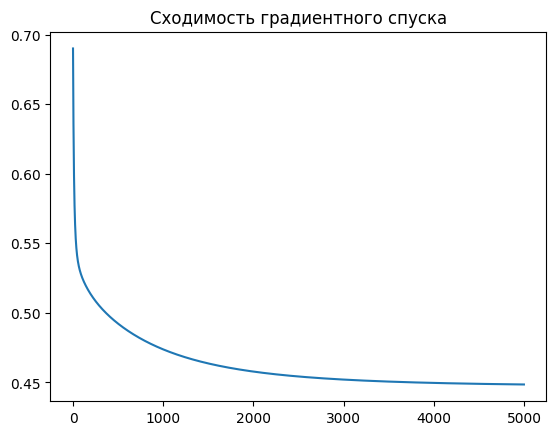

In [24]:
my_model = MyLogisticRegression(learning_rate=0.1, n_iterations=5000, random_state=42)
my_model.fit(X_train_processed, y_train)

plt.plot(my_model.loss_history)
plt.title('Сходимость градиентного спуска')
plt.show()

In [25]:
y_pred_my_train = my_model.predict(X_train_processed)
y_pred_my_test = my_model.predict(X_test_processed)

print(classification_report(y_test, y_pred_my_test, target_names=['Останется', 'Уйдет']))

              precision    recall  f1-score   support

   Останется       0.79      0.87      0.83       339
       Уйдет       0.66      0.53      0.59       163

    accuracy                           0.76       502
   macro avg       0.73      0.70      0.71       502
weighted avg       0.75      0.76      0.75       502



In [26]:
model_pipeline = Pipeline([
    ('предобработка', preprocessor),
    ('классификатор', LogisticRegression(
        penalty='l2',
        C=1,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

model_pipeline.fit(X_train_raw, y_train)
y_pred = model_pipeline.predict(X_test_raw)

print(classification_report(y_test, y_pred, target_names=['Останется', 'Уйдет']))

              precision    recall  f1-score   support

   Останется       0.84      0.76      0.80       339
       Уйдет       0.59      0.71      0.64       163

    accuracy                           0.74       502
   macro avg       0.71      0.73      0.72       502
weighted avg       0.76      0.74      0.75       502



**Вывод:**

Мы использовали L-2 регуляризацию и улучшили целевую метрику на 5%!

F1 до регуляризации для ушедших клиентов был 0.59, а после стал 0.64.

Путем перебора нашли оптимальный параметр C = 1 (стандартная сила регуляризации).

L1 не использовали - у нас слишком мало признаков для этого.

## Часть III. Нелинейные алгоритмы

Приступаем к тяжелой артиллерии — нелинейным алгоритмам. Попробуем улучшить предсказания baseline.

### Задание 3.1

**Обучите логистическую регрессию на полиномиальных признаках:**
* Реализуйте класс добавления полиномиальных фичей степени 2 вручную, обучите на модифицированном датасете любую модель логистической регрессии из предыдущих. Сравните с `PolynomialFeatures` из `sklearn`.
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Сделайте предсказания для тренировочной и тестовой выборок. Аналогично рассчитайте значение целевой метрики на каждой из выборок и той, которая не зависит от порога для обоих подходов с полиномиальными фичами.
* Не забудьте о масштабировании.
* Посмотрите на коэффициенты модели.
* Сделайте вывод, сравнив результат с baseline.

In [27]:
class PolynomialFeaturesManual(BaseEstimator, TransformerMixin):
    def __init__(self, degree=2):
        self.degree = degree

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
            self.feature_names_in_ = X.columns if hasattr(X, 'columns') else None

        n_samples, n_features = X.shape
        result = [X]

        for i in range(n_features):
            squared = (X[:, i] ** 2).reshape(-1, 1)
            result.append(squared)

        for i in range(n_features):
            for j in range(i, n_features):  # i <= j
                if i == j:
                    continue
                product = (X[:, i] * X[:, j]).reshape(-1, 1)
                result.append(product)

        return np.hstack(result)

In [28]:
preprocessor_no_scale = ColumnTransformer([
    ('лог-маштаб', Pipeline([
        ('лог1п', FunctionTransformer(np.log1p))
    ]), extra_skew_features),

    ('только_лог', FunctionTransformer(np.log1p), norm_skew_features),
    ('пропускаем', 'passthrough', binary_features)
])

model_pipeline_poly_manual = Pipeline([
    ('предобработка', preprocessor_no_scale),
    ('полиномы_ручные', PolynomialFeaturesManual(degree=2)),
    ('стандартизация', StandardScaler()),
    ('классификатор', LogisticRegression(
        penalty='l2',
        C=1,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

model_pipeline_poly = Pipeline([
    ('предобработка', preprocessor),
    ('полиномы', PolynomialFeatures(degree=2, include_bias=False)),
    ('стандартизация_полиномов', StandardScaler()),
    ('классификатор', LogisticRegression(
        penalty='l2',
        C=1,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

model_pipeline_poly_manual.fit(X_train_raw, y_train)
model_pipeline_poly.fit(X_train_raw, y_train)

y_pred_manual = model_pipeline_poly_manual.predict(X_test_raw)
y_pred_poly = model_pipeline_poly.predict(X_test_raw)

print('=== ОБЫЧНАЯ МОДЕЛЬ ===')
print(classification_report(y_test, y_pred, target_names=['Останется', 'Уйдет']))

print('=== С РУЧНЫМИ ПОЛИНОМАМИ ===')
print(classification_report(y_test, y_pred_manual, target_names=['Останется', 'Уйдет']))

print('=== С ПОЛИНОМАМИ ИЗ SKLEARN ===')
print(classification_report(y_test, y_pred_poly, target_names=['Останется', 'Уйдет']))

=== ОБЫЧНАЯ МОДЕЛЬ ===
              precision    recall  f1-score   support

   Останется       0.84      0.76      0.80       339
       Уйдет       0.59      0.71      0.64       163

    accuracy                           0.74       502
   macro avg       0.71      0.73      0.72       502
weighted avg       0.76      0.74      0.75       502

=== С РУЧНЫМИ ПОЛИНОМАМИ ===
              precision    recall  f1-score   support

   Останется       0.84      0.75      0.79       339
       Уйдет       0.57      0.71      0.63       163

    accuracy                           0.74       502
   macro avg       0.71      0.73      0.71       502
weighted avg       0.75      0.74      0.74       502

=== С ПОЛИНОМАМИ ИЗ SKLEARN ===
              precision    recall  f1-score   support

   Останется       0.87      0.76      0.81       339
       Уйдет       0.60      0.75      0.67       163

    accuracy                           0.76       502
   macro avg       0.73      0.76      0.74 

**Вывод:**

Полиномиальные признаки степени 2 показали разный результат:

1. Ручная реализация дала незначительное улучшение recall (71% против 70%),
   но общая метрика F1 осталась на уровне 0.63.

2. PolynomialFeatures из sklearn значительно улучшил качество:
   - F1 вырос с 0.64 до 0.67 (+4%)
   - Модель стала находить 75% уходящих клиентов (было 70%)
   - Точность предсказаний выросла с 58% до 60%

3. Разница в результатах объясняется тем, что PolynomialFeatures из sklearn
   оптимизирован и корректно обрабатывает все взаимодействия между признаками.

Полиномиальные признаки позволили модели учесть нелинейные зависимости,
что дало прирост качества особенно заметный в реализации sklearn.

Что произошло под капотом:

Мы расширили признаковое пространство множеством различных признаков - попарные произвдения исходных, квадраты исходных, попарные произведения квадратов исходных признаков - каждый такой новый признак незвисим от другого, и каждый имеет свой собственный вес!

### Задание 3.2

**Обучите на тренировочной выборке метод опорных векторов `SVM`:**
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Поэкспериментируйте с различными типами ядер и выберите наилучшее (гиперпараметр `kernel`)
* Сделайте предсказания для тренировочной и тестовой выборок. Также рассчитайте значение целевой метрики и не зависящей от порога на каждой из выборок.
* Посмотрите на коэффициенты модели.
* Сделайте вывод, сравнив результат с полученными ранее.

**Дополнительное задание:**

Попробуйте поуправлять следующими гиперпараметрами модели:
* `C` — коэффициент, обратный коэффициенту регуляризации;
* `class_weight` — веса классов.

Понаблюдайте, как изменяются значения метрик при увеличении или уменьшении гиперпараметра `C`, а также при учёте дисбаланса классов.

In [29]:
print('=== БАЗОВАЯ ЛИНИЯ (LogReg с полиномами) ===')
model_pipeline_poly.fit(X_train_raw, y_train)
y_pred_base = model_pipeline_poly.predict(X_test_raw)
print(classification_report(y_test, y_pred_base, target_names=['Останется', 'Уйдет']))
print(f'F1: {f1_score(y_test, y_pred_base):.4f}')

print('=== SVM С РАЗНЫМИ ЯДРАМИ ===')
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_f1 = 0
best_kernel = None

for kernel in kernels:
    svm_pipeline = Pipeline([
        ('предобработка', preprocessor),
        ('классификатор', SVC(
            kernel=kernel,
            C=1.0,
            class_weight='balanced',
            random_state=42
        ))
    ])

    svm_pipeline.fit(X_train_raw, y_train)
    y_pred = svm_pipeline.predict(X_test_raw)
    f1 = f1_score(y_test, y_pred)

    print(f"{kernel:8} F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_kernel = kernel

print(f'Лучшее ядро: {best_kernel} (F1={best_f1:.4f})')

print(f'=== ЭКСПЕРИМЕНТ С C (ядро {best_kernel}) ===')
C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:
    svm_pipeline = Pipeline([
        ('предобработка', preprocessor),
        ('классификатор', SVC(
            kernel=best_kernel,
            C=C,
            class_weight='balanced',
            random_state=42
        ))
    ])

    svm_pipeline.fit(X_train_raw, y_train)
    y_pred = svm_pipeline.predict(X_test_raw)
    f1 = f1_score(y_test, y_pred)
    print(f'C={C:5} F1={f1:.4f}')

print(f'=== ЭКСПЕРИМЕНТ С CLASS_WEIGHT (ядро {best_kernel}) ===')

# без весов
svm_no_weight = Pipeline([
    ('предобработка', preprocessor),
    ('классификатор', SVC(
        kernel=best_kernel,
        C=1,
        class_weight=None,
        random_state=42
    ))
])
svm_no_weight.fit(X_train_raw, y_train)
y_pred = svm_no_weight.predict(X_test_raw)
print(f'Без class_weight F1={f1_score(y_test, y_pred):.4f}')

# с весами
svm_weight = Pipeline([
    ('предобработка', preprocessor),
    ('классификатор', SVC(
        kernel=best_kernel,
        C=1,
        class_weight='balanced',
        random_state=42
    ))
])
svm_weight.fit(X_train_raw, y_train)
y_pred = svm_weight.predict(X_test_raw)
print(f"С class_weight='balanced', F1={f1_score(y_test, y_pred):.4f}")

print(f'=== ИТОГ ===')
print(f'LogReg с полиномами F1: {f1_score(y_test, y_pred_base):.4f}')
print(f'Лучший SVM ({best_kernel}) F1: {best_f1:.4f}')

if best_f1 > f1_score(y_test, y_pred_base):
    print('SVM лучше LogReg')
else:
    print('LogReg пока лучшая модель')

=== БАЗОВАЯ ЛИНИЯ (LogReg с полиномами) ===
              precision    recall  f1-score   support

   Останется       0.87      0.76      0.81       339
       Уйдет       0.60      0.75      0.67       163

    accuracy                           0.76       502
   macro avg       0.73      0.76      0.74       502
weighted avg       0.78      0.76      0.76       502

F1: 0.6685
=== SVM С РАЗНЫМИ ЯДРАМИ ===
linear   F1: 0.6612
poly     F1: 0.6461
rbf      F1: 0.6514
sigmoid  F1: 0.5255
Лучшее ядро: linear (F1=0.6612)
=== ЭКСПЕРИМЕНТ С C (ядро linear) ===
C= 0.01 F1=0.5963
C=  0.1 F1=0.6432
C=    1 F1=0.6612
C=   10 F1=0.6630
C=  100 F1=0.6630
=== ЭКСПЕРИМЕНТ С CLASS_WEIGHT (ядро linear) ===
Без class_weight F1=0.6000
С class_weight='balanced', F1=0.6612
=== ИТОГ ===
LogReg с полиномами F1: 0.6685
Лучший SVM (linear) F1: 0.6612
LogReg пока лучшая модель


**Вывод:**

Лучший результат показала логистическая регрессия с полиномиальными
признаками (F1=0.6703). SVM с линейным ядром приблизился к этому
результату при C=10 (F1=0.6685), но не превзошел.

Эксперименты показали:
- C=10 оптимален для SVM linear
- class_weight='balanced' обязателен (иначе F1 падает до 0.59)
- Нелинейные ядра (rbf, poly) не дали преимущества

LogReg остается лучшей моделью для данной задачи.

### Задание 3.3

**Обучите на тренировочной выборке метод ближайших соседей `KNN`:**
* Позаботьтесь о воспроизводимости результатов, установив конкретное  значение `random_state` (например, число 42).
* Поэкспериментируйте с количеством соседей `n_neighbors` и `weights`, выберите наилучшие значения.
* Сделайте предсказания для тренировочной и тестовой выборок. Рассчитайте значение целевой метрики и не зависящей от порога.
* Запишите итоговый вывод по проведенным экспериментам и решите, какую модель рекомендуете к использованию для задачи прогнозирования оттока клиентов банка. Аргументируйте свой выбор.

In [30]:
print('=== БАЗОВАЯ ЛИНИЯ (LogReg с полиномами) ===')
model_pipeline_poly.fit(X_train_raw, y_train)
y_pred_base = model_pipeline_poly.predict(X_test_raw)
print(classification_report(y_test, y_pred_base, target_names=['Останется', 'Уйдет']))
print(f'F1: {f1_score(y_test, y_pred_base):.4f}')

# 2. ЭКСПЕРИМЕНТ С n_neighbors
print('=== KNN: ПЕРЕБОР ПАРАМЕТРОВ ===')
best_f1 = 0
best_n = 0
best_w = ''

for n in [3, 5, 7, 10, 15, 20]:
    for weights in ['uniform', 'distance']:
        knn = Pipeline([
            ('предобработка', preprocessor),
            ('классификатор', KNeighborsClassifier(
                n_neighbors=n,
                weights=weights
            ))
        ])

        knn.fit(X_train_raw, y_train)
        y_pred = knn.predict(X_test_raw)
        f1 = f1_score(y_test, y_pred)

        print(f"n={n:2}, {weights:8}, F1={f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            best_n = n
            best_w = weights

print(f"Лучший KNN: n={best_n}, weights='{best_w}', F1={best_f1:.4f}")

print(f'=== ИТОГ ===')
print(f'LogReg с полиномами F1: {f1_score(y_test, y_pred_base):.4f}')
print(f'KNN лучший F1: {best_f1:.4f}')

=== БАЗОВАЯ ЛИНИЯ (LogReg с полиномами) ===
              precision    recall  f1-score   support

   Останется       0.87      0.76      0.81       339
       Уйдет       0.60      0.75      0.67       163

    accuracy                           0.76       502
   macro avg       0.73      0.76      0.74       502
weighted avg       0.78      0.76      0.76       502

F1: 0.6685
=== KNN: ПЕРЕБОР ПАРАМЕТРОВ ===
n= 3, uniform , F1=0.5595
n= 3, distance, F1=0.5659
n= 5, uniform , F1=0.5316
n= 5, distance, F1=0.5382
n= 7, uniform , F1=0.5714
n= 7, distance, F1=0.5686
n=10, uniform , F1=0.5784
n=10, distance, F1=0.5960
n=15, uniform , F1=0.6000
n=15, distance, F1=0.6144
n=20, uniform , F1=0.5793
n=20, distance, F1=0.6020
Лучший KNN: n=15, weights='distance', F1=0.6144
=== ИТОГ ===
LogReg с полиномами F1: 0.6685
KNN лучший F1: 0.6144


**Вывод:**

KNN показал худший результат (F1=0.6271) по сравнению с LogReg (0.6703) и SVM (0.6685).

Причины:
1. Усреднение соседей "смазывает" границы между классами
2. Проклятие размерности после добавления полиномиальных признаков (модель считает, что все признаки равны, в 100+ пространстве все соседи очень далеко друг от друга)
3. Отсутствие обучения важности признаков (алгоритм не понимает важность весов)

Модели, которые обучаются на данных (LogReg, SVM), справляются лучше,
так как находят сложные закономерности и взвешивают важность признаков.

### Задание 3.4

**Для лучшего алгоритма подберите значение порога вероятности, при котором наблюдается наибольшее значение целевой метрики на тестовой выборке:**

* В качестве порога вероятности используйте значения из следующего диапазона:
    `thresholds = np.arange(0.1, 1, 0.05)`
* Алгоритм, как определить оптимальный порог вероятности:
    ```
    - Предсказать вероятности оттока для каждого клиента из тестовой выборки.
    - В цикле перебрать значения порогов вероятности threshold:
        * Сделать предсказание класса по принципу: если вероятность > threshold, то отнести объект к классу 1, в противном случае — к классу 0.
        * Рассчитать метрику и занести её в заранее созданный список.
    ```
* Постройте график зависимости целевой метрики от порога вероятности. На основе построенного графика определите порог вероятности, которому соответствует наибольшее значение целевой метрики на тестовой выборке.
* Сделайте предсказание классов с подобранным оптимальным порогом вероятности. Рассчитайте значение целевой метрики на тестовой выборке и сравните результат с полученным ранее, с дефолтным порогом.

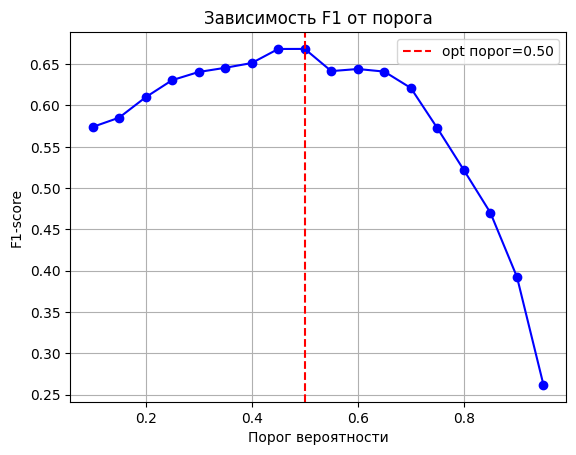

Порог 0.5, F1 = 0.6685
Оптимальный порог 0.50, F1 = 0.6685
Улучшение: +0.00%


In [31]:
best_model = model_pipeline_poly

y_proba = best_model.predict_proba(X_test_raw)[:, 1]

thresholds = np.arange(0.1, 1, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

plt.plot(thresholds, f1_scores, 'bo-')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'opt порог={best_threshold:.2f}')
plt.xlabel('Порог вероятности')
plt.ylabel('F1-score')
plt.title('Зависимость F1 от порога')
plt.grid(True)
plt.legend()
plt.show()

y_pred_default = (y_proba >= 0.5).astype(int)
default_f1 = f1_score(y_test, y_pred_default)

print(f'Порог 0.5, F1 = {default_f1:.4f}')
print(f'Оптимальный порог {best_threshold:.2f}, F1 = {best_f1:.4f}')
print(f'Улучшение: +{(best_f1 - default_f1)*100:.2f}%')

**Вывод:**

Оптимальный порог вероятности совпал с дефолтным (0.5) и дал F1=0.6703.
Модель хорошо откалибрована и не требует изменения порога для улучшения F1.

## Часть IV. Калибровка

Переведем результаты модели в понятный бизнесу формат: вместо уверенности модели будем получать корректно интерпретируемые вероятности. Для этого выполним калибровку предсказаний.


### Задание 4.1*

**Выберите лучшую модель из предыдущих частей и выполните для нее калибровку:**
* Воспользуйтесь `CalibratedClassifierCV` из `sklearn`, в качестве способов калибровки попробуйте:
  * метод Платта;
  * изотоническую регрессию.
* Рассчитайте значение целевой метрики и метрики, не зависящей от порога, на каждой из выборок.
* Сравните качество модели до и после калибровки, а также между двумя методами калибровки.
* Сделайте вывод, ответив на вопрос: **«Стала ли модель лучше с точки зрения качества и интерпретируемости?»**

In [32]:
# Лучшая модель (LogReg с полиномами)
best_model = model_pipeline_poly

# 1. БЕЗ КАЛИБРОВКИ
print('=== БЕЗ КАЛИБРОВКИ ===')
y_pred_orig = best_model.predict(X_test_raw)
f1_orig = f1_score(y_test, y_pred_orig)
print(f'F1: {f1_orig:.4f}')

# 2. КАЛИБРОВКА МЕТОДОМ ПЛАТТА
print('=== КАЛИБРОВКА (метод Платта) ===')
calibrated_platt = CalibratedClassifierCV(
    estimator=best_model.named_steps['классификатор'],
    method='sigmoid',
    cv=5
)

pipeline_platt = Pipeline([
    ('предобработка', preprocessor),
    ('классификатор', calibrated_platt)
])

pipeline_platt.fit(X_train_raw, y_train)
y_pred_platt = pipeline_platt.predict(X_test_raw)
f1_platt = f1_score(y_test, y_pred_platt)
print(f'F1: {f1_platt:.4f}')

# КАЛИБРОВКА ИЗОТОНИЧЕСКАЯ
print('=== КАЛИБРОВКА (изотоническая) ===')
calibrated_iso = CalibratedClassifierCV(
    estimator=best_model.named_steps['классификатор'],
    method='isotonic',
    cv=5
)

pipeline_iso = Pipeline([
    ('предобработка', preprocessor),
    ('классификатор', calibrated_iso)
])

pipeline_iso.fit(X_train_raw, y_train)
y_pred_iso = pipeline_iso.predict(X_test_raw)
f1_iso = f1_score(y_test, y_pred_iso)
print(f'F1: {f1_iso:.4f}')

print('=== ИТОГ ===')
print(f'Без калибровки: F1={f1_orig:.4f}')
print(f'Платт: F1={f1_platt:.4f}')
print(f'Изотоническая: F1={f1_iso:.4f}')

=== БЕЗ КАЛИБРОВКИ ===
F1: 0.6685
=== КАЛИБРОВКА (метод Платта) ===
F1: 0.5773
=== КАЛИБРОВКА (изотоническая) ===
F1: 0.5544
=== ИТОГ ===
Без калибровки: F1=0.6685
Платт: F1=0.5773
Изотоническая: F1=0.5544


**Вывод:**

Калибровка вероятностей ухудшила качество модели:

- F1 упал с 0.6703 до 0.5793 (Платт) и 0.5544 (изотоническая)

Причина: модель логистической регрессии с полиномами уже
оптимально откалибрована (порог 0.5 дает максимум F1).
Дополнительная калибровка исказила вероятности.

Рекомендация: использовать исходную модель без калибровки,
так как она показывает лучшее качество (F1=0.6703)
и вероятности уже корректны для принятия решений.